In [33]:
import numpy as np
import pickle # Import the pickle module
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import visual

cuda:0


In [34]:
def single_S(y,x_left,x_right,y_below,y_upper,center,r): # Single source
    return np.exp(-300*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): # Total source
    S_1= single_S(y,x_left,x_right,y_below,y_upper,center[0],r)
    S_2= single_S(y,x_left,x_right,y_below,y_upper,center[1],r)
    S_3= single_S(y,x_left,x_right,y_below,y_upper,center[2],r)
    S_4= single_S(y,x_left,x_right,y_below,y_upper,center[3],r)
    return S_1+S_2+S_3+S_4

def load_s_num_field(path):
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr[-1]
    if arr.ndim == 2:
        return arr
    raise ValueError(
        f"{path} has shape {arr.shape}, not a 2D field. "
        "For 0.5pi/pi, rerun the source notebook after fixing the main.ada_int return order."
    )


Plot saved as ./results/0.25pi/S_num_1_4.pdf


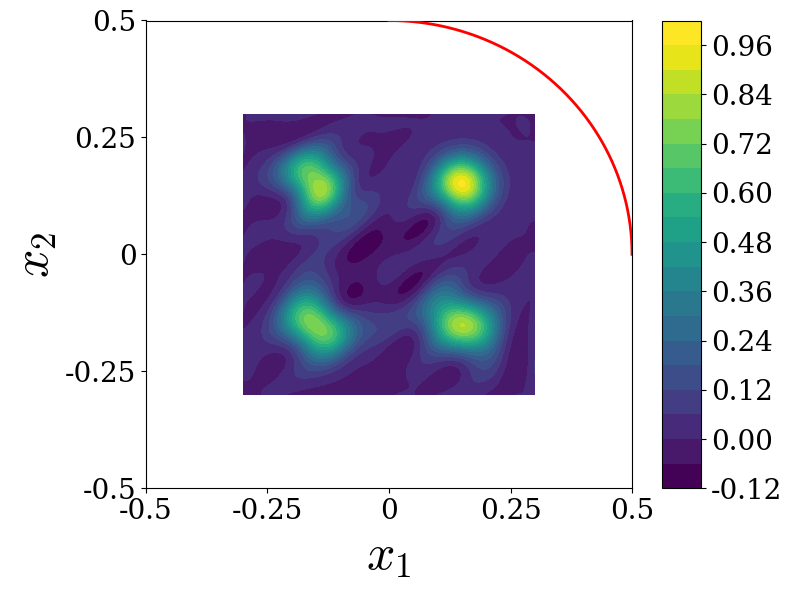

In [35]:
reload(visual)
S_num_1_4 = load_s_num_field("./results/0.25pi/S_num_store.npy")
x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
output_dictionary="./results/0.25pi/"
visual.draw(X, Y, S_num_1_4, output_dictionary, "S_num_1_4.pdf", cmap="viridis", label_size=36, tick_size=20, colorbar_tick_size=20, tick_format="{:g}", colorbar_tick_format="{:.2f}", x_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], y_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], arc_alpha=0.25)

Plot saved as ./results/0.5pi/S_num_1_2.pdf


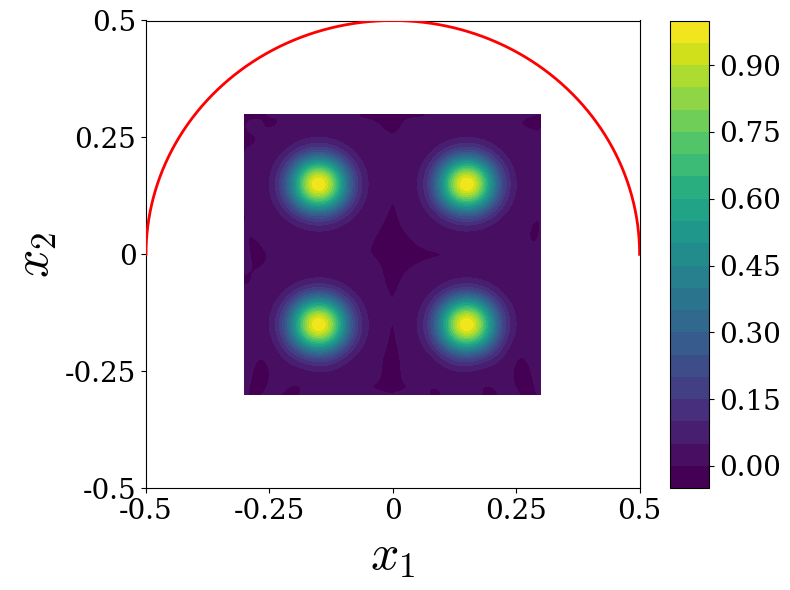

In [36]:
S_num_1_2 = load_s_num_field("./results/0.5pi/S_num_store.npy")
output_dictionary="./results/0.5pi/"
visual.draw(X, Y, S_num_1_2, output_dictionary, "S_num_1_2.pdf", cmap="viridis", label_size=36, tick_size=20, colorbar_tick_size=20, tick_format="{:g}", colorbar_tick_format="{:.2f}", x_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], y_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], arc_alpha=0.5)

Plot saved as ./results/0.75pi/S_num_3_4.pdf


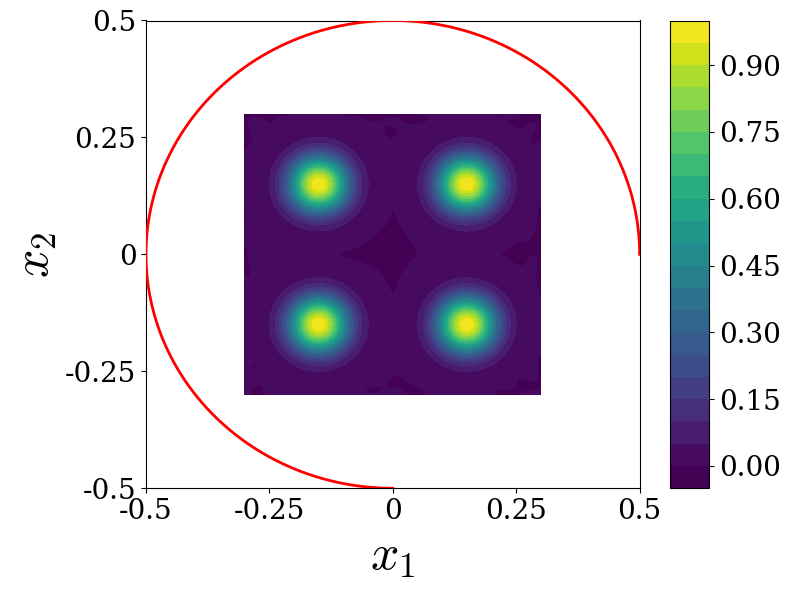

In [37]:
S_num_3_4 = load_s_num_field("./results/0.75pi/S_num_store.npy")
output_dictionary="./results/0.75pi/"
visual.draw(X, Y, S_num_3_4, output_dictionary, "S_num_3_4.pdf", cmap="viridis", label_size=36, tick_size=20, colorbar_tick_size=20, tick_format="{:g}", colorbar_tick_format="{:.2f}", x_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], y_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], arc_alpha=0.75)

Plot saved as ./results/pi/S_num_1.pdf


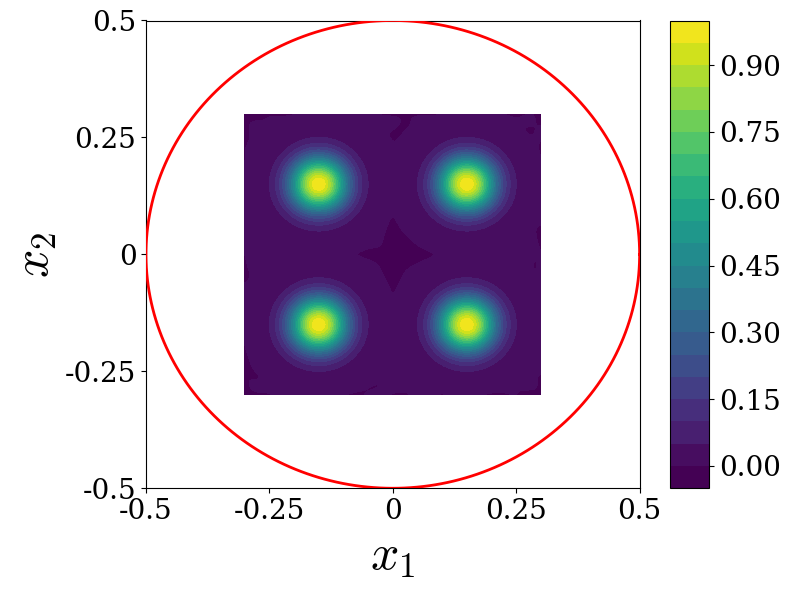

In [38]:
S_num_1 = load_s_num_field("./results/pi/S_num_store.npy")
output_dictionary="./results/pi/"
visual.draw(X, Y, S_num_1, output_dictionary, "S_num_1.pdf", cmap="viridis", label_size=36, tick_size=20, colorbar_tick_size=20, tick_format="{:g}", colorbar_tick_format="{:.2f}", x_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], y_ticks=[-0.5, -0.25, 0.0, 0.25, 0.5], arc_alpha=1.0)